# Read state_transfer Results

Load result files written by `state_transfer/main_HF.py` and recreate the VQE / CMX plots. Set `shots`, `MOLECULE`, and `BOND_LENGTH` in the first code cell to choose a run such as `data/8192shots/HF_bond_1.2` or `data/8192shots/HF_bond_2.2`. The notebook plots VQE convergence/error from `vqe_results.json` and shows CMX/CME only when non-empty sweep data is present.

In [1]:
from pathlib import Path
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 140})

# state_transfer/main_HF.py writes under state_transfer/data/<shots>shots/<MOLECULE>_bond_<bond>/
# Resolve relative to this notebook so it works regardless of the kernel cwd.
NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "data").is_dir() and (NOTEBOOK_DIR / "state_transfer" / "data").is_dir():
    NOTEBOOK_DIR = NOTEBOOK_DIR / "state_transfer"
DATA_ROOT = NOTEBOOK_DIR / "data"

shots = 8192  # e.g. 8192 -> data/8192shots, 81920 -> data/81920shots
MOLECULE = "HF"
BOND_LENGTH = 2.2  # switch to 2.2 for the other run
SHOTS_DIR = DATA_ROOT / f"{shots}shots"
RUN_DIR = SHOTS_DIR / f"{MOLECULE}_bond_{BOND_LENGTH:.1f}"

shot_dirs = sorted(p for p in DATA_ROOT.glob("*shots") if p.is_dir())
print("Available shot budgets:")
for i, shot_dir in enumerate(shot_dirs):
    print(f"{i}: {shot_dir}")

if not SHOTS_DIR.is_dir():
    available = ", ".join(str(p) for p in shot_dirs) or "none"
    raise FileNotFoundError(
        f"Shots directory not found: {SHOTS_DIR}. "
        f"Set shots to one of the available budgets: {available}"
    )

runs = sorted(p for p in SHOTS_DIR.glob("*_bond_*") if p.is_dir())
print(f"\nAvailable runs under {SHOTS_DIR}:")
for i, run in enumerate(runs):
    print(f"{i}: {run}")

if not RUN_DIR.is_dir():
    available = ", ".join(str(run) for run in runs) or "none"
    raise FileNotFoundError(
        f"Run directory not found: {RUN_DIR}. "
        f"Set MOLECULE/BOND_LENGTH to one of the available runs: {available}"
    )

print(f"\nSelected run: {RUN_DIR}")
RUN_DIR


Available shot budgets:
0: /Users/zacharyhe/cross_chips_sim/state_transfer/data/81920shots
1: /Users/zacharyhe/cross_chips_sim/state_transfer/data/8192shots

Available runs under /Users/zacharyhe/cross_chips_sim/state_transfer/data/8192shots:
0: /Users/zacharyhe/cross_chips_sim/state_transfer/data/8192shots/HF_bond_1.2
1: /Users/zacharyhe/cross_chips_sim/state_transfer/data/8192shots/HF_bond_2.2

Selected run: /Users/zacharyhe/cross_chips_sim/state_transfer/data/8192shots/HF_bond_2.2


PosixPath('/Users/zacharyhe/cross_chips_sim/state_transfer/data/8192shots/HF_bond_2.2')

In [2]:
EXPECTED_FILES = (
    "run_summary.json",
    "vqe_results.json",
    "vqe_results.pkl",
    "cme_results.json",
    "cme_results_by_multiplier.json",
    "all_results.pkl",
)


def load_json(name):
    path = RUN_DIR / name
    if not path.exists() or path.stat().st_size == 0:
        return None
    try:
        return json.loads(path.read_text())
    except json.JSONDecodeError:
        print(f"Warning: {path.name} exists but is not valid JSON; ignoring.")
        return None


def load_pickle(name):
    path = RUN_DIR / name
    if not path.exists() or path.stat().st_size == 0:
        return None
    with path.open("rb") as handle:
        return pickle.load(handle)


def as_float_array(records, key):
    return np.asarray([float(row[key]) for row in records], dtype=float)


def inventory_run_dir():
    print("Run file inventory:")
    for name in EXPECTED_FILES:
        path = RUN_DIR / name
        if not path.exists():
            status = "missing"
        elif path.stat().st_size == 0:
            status = "empty"
        else:
            status = f"ok ({path.stat().st_size:,} B)"
        print(f"  {name:<32} {status}")


inventory_run_dir()

summary = load_json("run_summary.json") or {}
vqe_results = load_json("vqe_results.json")
if vqe_results is None:
    vqe_results = load_pickle("vqe_results.pkl")
    if vqe_results is not None:
        print("Loaded VQE results from vqe_results.pkl (JSON missing or empty).")

cme_results = load_json("cme_results.json")
if cme_results is None:
    cme_results = load_pickle("cme_results.pkl")

cme_by_multiplier = load_json("cme_results_by_multiplier.json") or {}
if not cme_by_multiplier:
    cme_by_multiplier = load_pickle("cme_results_by_multiplier.pkl") or {}

molecule = summary.get("molecule", RUN_DIR.name.split("_bond_")[0])
bond_length = float(summary.get("bond_length", RUN_DIR.name.split("_bond_")[-1]))

# Exact ground-state references (Hartree) from Pauli_Ham bond scans / saved CMX runs.
KNOWN_GS_ENERGIES = {
    ("HF", 1.2): -98.57387833667892,
    ("HF", 2.2): -98.45842350054684,
    ("Cl2", 2.2): -909.143531683094,
}

e_ref = None
if cme_by_multiplier:
    first_cme = next(iter(cme_by_multiplier.values()))
    e_ref = first_cme.get("e_gs")
if e_ref is None:
    e_ref = KNOWN_GS_ENERGIES.get((molecule, round(bond_length, 1)))
if e_ref is None:
    print(
        "Warning: no ground-state reference for this run. "
        "VQE error plots will be skipped; add an entry to KNOWN_GS_ENERGIES."
    )
else:
    e_ref = float(e_ref)

print(json.dumps(summary, indent=2))
if e_ref is not None:
    print(f"Ground-state reference: {e_ref:.12f} Eh")
print(f"Has VQE curves: {vqe_results is not None}")
print(f"Has CMX sweep: {bool(cme_by_multiplier)}")


Run file inventory:
  run_summary.json                 ok (396 B)
  vqe_results.json                 ok (13,737 B)
  vqe_results.pkl                  ok (5,624 B)
  cme_results.json                 ok (13,360 B)
  cme_results_by_multiplier.json   ok (42,568 B)
  all_results.pkl                  ok (19,608 B)
{
  "bond_length": 2.2,
  "created_utc": "2026-07-14T10:46:18.243621+00:00",
  "has_cme_results": true,
  "has_cme_results_by_multiplier": true,
  "has_vqe_results": true,
  "metadata": {
    "cdr_training_circuits": 30,
    "circuit_name": "HF_tapered_6q_3doubles_rzx_qst",
    "measurement_scheme": "ogm",
    "num_shots": 8192,
    "vqe_iters": 15
  },
  "molecule": "HF",
  "stage": "final"
}
Ground-state reference: -98.458423500547 Eh
Has VQE curves: True
Has CMX sweep: True


Using true GS reference energy: -98.458423500547 Eh
Best REM+CF energy: -98.484150540576 Eh
Best REM+CF error: 2.572704e-02 Eh

REM+CF energy by iteration:
  iter         REM+CF (Eh)   |E - E_GS| (Eh)
     0    -98.288461878448      1.699616e-01
     1    -98.217599372336      2.408241e-01
     2    -98.212787541986      2.456360e-01
     3    -98.278301408186      1.801221e-01
     4    -98.332057973892      1.263655e-01
     5    -98.344137268146      1.142862e-01
     6    -98.339016313474      1.194072e-01
     7    -98.353346055545      1.050774e-01
     8    -98.408037356675      5.038614e-02
     9    -98.436098422628      2.232508e-02
    10    -98.354092688098      1.043308e-01
    11    -98.473995700612      1.557220e-02
    12    -98.434430170564      2.399333e-02
    13    -98.484150540576      2.572704e-02
    14    -98.369968768682      8.845473e-02
    15    -98.462895951878      4.472451e-03


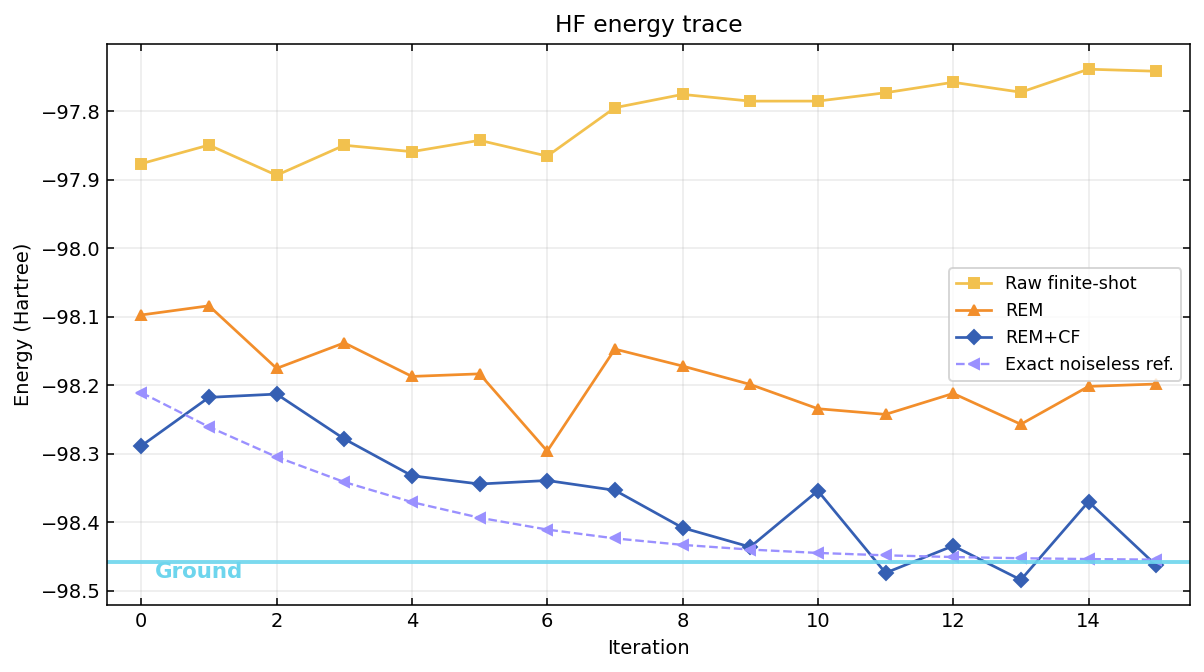

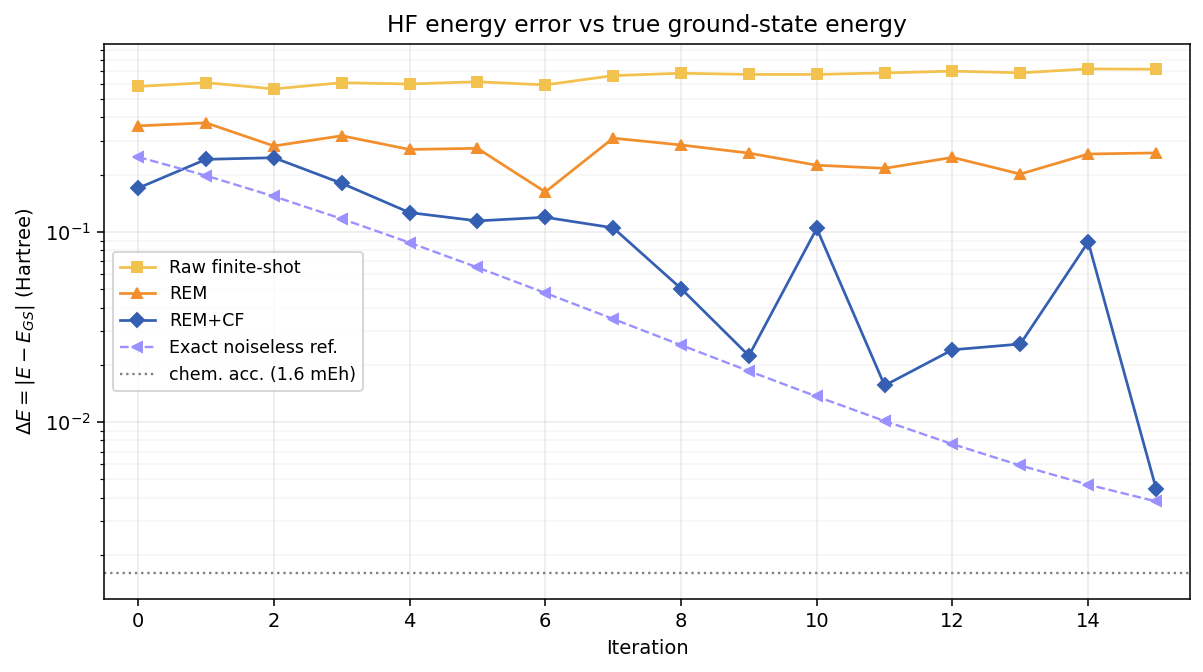

In [3]:
# --- VQE plots from saved state_transfer data: energy trace + log-scale error vs true GS ---
if vqe_results is None:
    print("No VQE results found in", RUN_DIR)
elif e_ref is None:
    print("Skipping VQE plots: ground-state reference unavailable for", RUN_DIR.name)
else:
    ec = vqe_results["energy_curves"]
    xs = as_float_array(ec, "iter")
    raw = as_float_array(ec, "raw_eh")
    rem = as_float_array(ec, "rem_eh")
    cf = as_float_array(ec, "rem_cf_eh")
    nls = as_float_array(ec, "noiseless_eh")

    style_raw = dict(color="#f2c14e", marker="s", ms=5, lw=1.4, label="Raw finite-shot")
    style_rem = dict(color="#f28e2b", marker="^", ms=5, lw=1.4, label="REM")
    style_cf = dict(color="#355fb3", marker="D", ms=4.8, lw=1.4, label="REM+CF")
    style_nls = dict(color="#9a90ff", marker="<", ms=5, lw=1.2, linestyle="--", label="Exact noiseless ref.")

    # ---- Energy trace ----
    fig1, ax1 = plt.subplots(figsize=(8.7, 4.9))
    ax1.plot(xs, raw, **style_raw)
    ax1.plot(xs, rem, **style_rem)
    ax1.plot(xs, cf, **style_cf)
    ax1.plot(xs, nls, **style_nls)
    ax1.axhline(e_ref, color="#6dd5ed", lw=2.0, alpha=0.9)
    ax1.text(xs.min() + 0.2, e_ref, "Ground", color="#6dd5ed", va="top", ha="left", fontsize=11, weight="bold")

    all_e = np.concatenate([raw, rem, cf, nls, [e_ref]])
    lo, hi = float(all_e.min()), float(all_e.max())
    pad = 0.05 * (hi - lo + 1e-9)
    ax1.set_xlim(xs.min() - 0.5, xs.max() + 0.5)
    ax1.set_ylim(lo - pad, hi + pad)
    ax1.tick_params(axis="both", which="both", direction="in", top=True, right=True)
    ax1.set_xlabel("Iteration")
    ax1.set_ylabel("Energy (Hartree)")
    ax1.set_title(f"{molecule} energy trace")
    ax1.grid(True, alpha=0.25)
    ax1.legend(loc="best", fontsize=9)
    fig1.tight_layout()

    # ---- Absolute error vs true GS (log-y) ----
    floor = 1e-16
    err_raw = np.maximum(np.abs(raw - e_ref), floor)
    err_rem = np.maximum(np.abs(rem - e_ref), floor)
    err_cf = np.maximum(np.abs(cf - e_ref), floor)
    err_nls = np.maximum(np.abs(nls - e_ref), floor)

    fig2, ax2 = plt.subplots(figsize=(8.7, 4.9))
    ax2.plot(xs, err_raw, **style_raw)
    ax2.plot(xs, err_rem, **style_rem)
    ax2.plot(xs, err_cf, **style_cf)
    ax2.plot(xs, err_nls, **style_nls)
    ax2.set_yscale("log")
    ax2.axhline(1.6e-3, color="gray", ls=":", lw=1.2, label="chem. acc. (1.6 mEh)")
    ax2.set_xlim(xs.min() - 0.5, xs.max() + 0.5)
    ax2.set_xlabel("Iteration")
    ax2.set_ylabel(r"$\Delta E = |E - E_{GS}|$ (Hartree)")
    ax2.set_title(f"{molecule} energy error vs true ground-state energy")
    ax2.grid(True, which="major", alpha=0.25)
    ax2.grid(True, which="minor", alpha=0.12)
    ax2.legend(loc="best", fontsize=9)
    fig2.tight_layout()

    print(f"Using true GS reference energy: {e_ref:.12f} Eh")
    print(f"Best REM+CF energy: {float(vqe_results['E_best']):.12f} Eh")
    print(f"Best REM+CF error: {abs(float(vqe_results['E_best']) - e_ref):.6e} Eh")
    print("\nREM+CF energy by iteration:")
    print(f"{'iter':>6}  {'REM+CF (Eh)':>18}  {'|E - E_GS| (Eh)':>16}")
    for i, e in zip(xs, cf):
        print(f"{int(i):6d}  {float(e):18.12f}  {abs(float(e) - e_ref):16.6e}")
    plt.show()


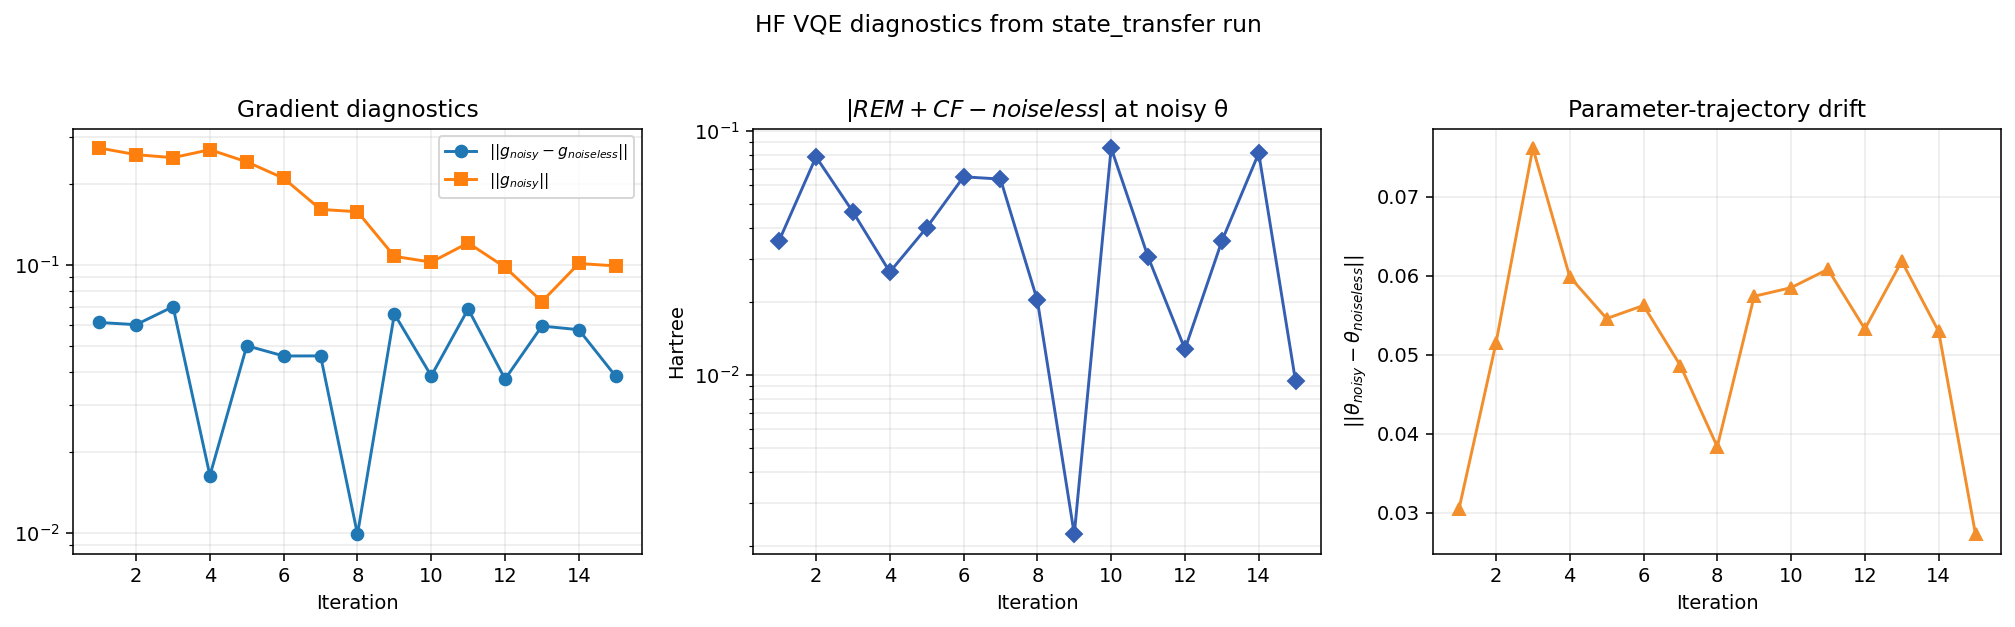

Measurement cost summary
  total CDR calls       : 107
  energy evals/call     : 31
  shots/eval            : 8192
  estimated total shots : 27,172,864
  calls by stage        : {'final': 1, 'init': 1, 'main_grad': 90, 'main_post': 15, 'noiseless_track': 32, 'total': 107, 'warmup': 0}


In [4]:
# --- Extra VQE diagnostics saved by the state_transfer run ---
if vqe_results is None or not vqe_results.get("trace"):
    print("No VQE trace diagnostics found in", RUN_DIR)
else:
    trace = vqe_results["trace"]
    it = as_float_array(trace, "iter")
    grad_diff = as_float_array(trace, "grad_diff")
    grad_norm = as_float_array(trace, "grad_noisy_norm")
    theta_diff = as_float_array(trace, "theta_diff")
    e_bias = as_float_array(trace, "e_bias")

    fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.3))

    axes[0].plot(it, grad_diff, marker="o", lw=1.5, label=r"$||g_{noisy}-g_{noiseless}||$")
    axes[0].plot(it, grad_norm, marker="s", lw=1.5, label=r"$||g_{noisy}||$")
    axes[0].set_yscale("log")
    axes[0].set_xlabel("Iteration")
    axes[0].set_title("Gradient diagnostics")
    axes[0].grid(True, which="both", alpha=0.25)
    axes[0].legend(fontsize=8)

    axes[1].plot(it, e_bias, marker="D", color="#355fb3", lw=1.5)
    axes[1].set_yscale("log")
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Hartree")
    axes[1].set_title(r"$|REM+CF - noiseless|$ at noisy θ")
    axes[1].grid(True, which="both", alpha=0.25)

    axes[2].plot(it, theta_diff, marker="^", color="#f28e2b", lw=1.5)
    axes[2].set_xlabel("Iteration")
    axes[2].set_ylabel(r"$||\theta_{noisy}-\theta_{noiseless}||$")
    axes[2].set_title("Parameter-trajectory drift")
    axes[2].grid(True, alpha=0.25)

    fig.suptitle(f"{molecule} VQE diagnostics from state_transfer run", y=1.03)
    fig.tight_layout()
    plt.show()

    cost = vqe_results.get("cost_model", {})
    counts = vqe_results.get("counts", {})
    if cost:
        print("Measurement cost summary")
        print(f"  total CDR calls       : {cost.get('total_cdr_calls', counts.get('total'))}")
        print(f"  energy evals/call     : {cost.get('energy_evals_per_cdr_call')}")
        print(f"  shots/eval            : {cost.get('num_shots_per_eval')}")
        print(f"  estimated total shots : {cost.get('total_shots_est'):,}")
        print(f"  calls by stage        : {counts}")


CMX/CME variance and shot-budget results: HF_bond_2.2


,H2/H3 multiplier,variance repeats,H shots/repeat,H2 shots/repeat,H3 shots/repeat,<H> noiseless (Eh),<H2> noiseless (Eh^2),<H3> noiseless (Eh^3),E_cme noiseless (Eh),|noiseless CME - GS| (mEh),...,Var[E_cme] (Eh^2),sigma propagated (Eh),sigma empirical (Eh),E_cme - 1 sigma (Eh),E_cme - 2 sigma (Eh),E_gs (Eh),|shot CME - GS| (mEh),|CME-1sigma - GS| (mEh),|CME-2sigma - GS| (mEh),shot CME below chem. acc. (1.6 mEh)
0,5,10,40960,40960,40960,-98.448779,9692.168708,-954183.477711,-98.454695,3.728337,...,0.223483,0.472739,0.008009,-98.864914,-99.337654,-98.458424,66.248416,406.490952,879.230320,False
1,10,10,81920,81920,81920,-98.448779,9692.168708,-954183.477711,-98.454695,3.728337,...,0.000009,0.003004,0.009085,-98.455626,-98.458631,-98.458424,5.801384,2.797115,0.207153,False
2,20,10,163840,163840,163840,-98.448779,9692.168708,-954183.477711,-98.454695,3.728337,...,0.000009,0.002926,0.004343,-98.448712,-98.451638,-98.458424,12.638305,9.711814,6.785323,False


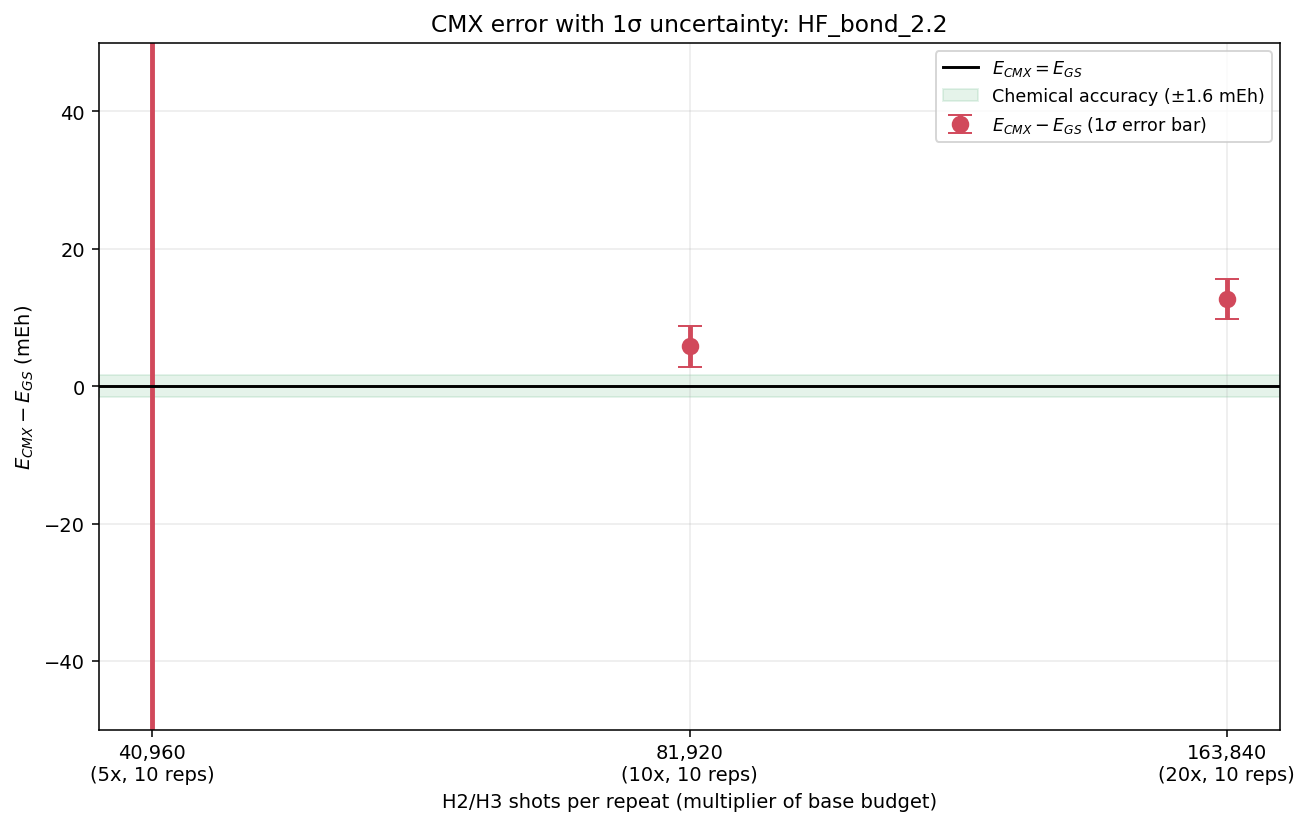

In [5]:
# --- CMX/CME energy error table when sweep data exists ---
import pandas as pd
from IPython.display import display

if not cme_by_multiplier:
    print("No non-empty CMX/CME sweep results found in", RUN_DIR)
else:
    rows = []
    for mult, result in sorted((int(k), v) for k, v in cme_by_multiplier.items()):
        shots = result["shots"]
        moments = result["moments"]
        e_cme = float(result["E_cme_shots"])
        e_cme_noiseless = float(result["E_cme_noiseless"])
        e_gs = float(result["e_gs"])
        variance = float(result.get("E_cme_variance", np.nan))
        sigma = float(result.get("E_cme_sigma", np.sqrt(variance)))
        e_minus_1sigma = float(result.get("E_cme_minus_1sigma", e_cme - sigma))
        e_minus_2sigma = float(result.get("E_cme_minus_2sigma", e_cme - 2.0 * sigma))
        empirical_sigma = float(result.get("E_cme_empirical_sigma", np.nan))
        repeats = int(result.get("variance_repeats", 1))
        err_gs = abs(e_cme - e_gs)
        noiseless_err_gs = abs(e_cme_noiseless - e_gs)
        rows.append(
            {
                "H2/H3 multiplier": mult,
                "variance repeats": repeats,
                "H shots/repeat": int(shots["H"]),
                "H2 shots/repeat": int(shots["H2"]),
                "H3 shots/repeat": int(shots["H3"]),
                "<H> noiseless (Eh)": float(moments["H"]["noiseless"]),
                "<H2> noiseless (Eh^2)": float(moments["H2"]["noiseless"]),
                "<H3> noiseless (Eh^3)": float(moments["H3"]["noiseless"]),
                "E_cme noiseless (Eh)": e_cme_noiseless,
                "|noiseless CME - GS| (mEh)": noiseless_err_gs * 1e3,
                "E_cme shots (Eh)": e_cme,
                "Var[E_cme] (Eh^2)": variance,
                "sigma propagated (Eh)": sigma,
                "sigma empirical (Eh)": empirical_sigma,
                "E_cme - 1 sigma (Eh)": e_minus_1sigma,
                "E_cme - 2 sigma (Eh)": e_minus_2sigma,
                "E_gs (Eh)": e_gs,
                "|shot CME - GS| (mEh)": err_gs * 1e3,
                "|CME-1sigma - GS| (mEh)": abs(e_minus_1sigma - e_gs) * 1e3,
                "|CME-2sigma - GS| (mEh)": abs(e_minus_2sigma - e_gs) * 1e3,
                "shot CME below chem. acc. (1.6 mEh)": err_gs <= 1.6e-3,
            }
        )

    cme_error_table = pd.DataFrame(rows)
    print(f"CMX/CME variance and shot-budget results: {RUN_DIR.name}")
    display(cme_error_table)

    # One CMX-minus-ground-state line with configurable 1σ or 2σ error bars.
    CMX_ERRORBAR_SIGMAS = 1  # set to 2 for two-sigma error bars
    if CMX_ERRORBAR_SIGMAS not in (1, 2):
        raise ValueError("CMX_ERRORBAR_SIGMAS must be 1 or 2.")

    shot_counts = cme_error_table["H2 shots/repeat"].to_numpy(dtype=float)
    multipliers = cme_error_table["H2/H3 multiplier"].to_numpy(dtype=int)
    repeats = cme_error_table["variance repeats"].to_numpy(dtype=int)
    shot_tick_labels = [
        f"{int(s):,}\n({m}x, {r} reps)"
        for s, m, r in zip(shot_counts, multipliers, repeats)
    ]
    signed_error_meh = (
        cme_error_table["E_cme shots (Eh)"].to_numpy(dtype=float)
        - cme_error_table["E_gs (Eh)"].to_numpy(dtype=float)
    ) * 1e3
    yerr_meh = (
        CMX_ERRORBAR_SIGMAS
        * cme_error_table["sigma propagated (Eh)"].to_numpy(dtype=float)
        * 1e3
    )

    fig, ax = plt.subplots(figsize=(9.5, 6.0))
    ax.errorbar(
        shot_counts,
        signed_error_meh,
        yerr=yerr_meh,
        marker="o",
        linestyle="none",
        markersize=8,
        linewidth=2.5,
        capsize=6,
        color="#d1495b",
        label=rf"$E_{{CMX}}-E_{{GS}}$ ({CMX_ERRORBAR_SIGMAS}$\sigma$ error bar)",
    )
    ax.axhline(0.0, color="black", linewidth=1.5, label="$E_{CMX}=E_{GS}$")
    ax.axhspan(-1.6, 1.6, color="#2a9d55", alpha=0.12, label="Chemical accuracy (±1.6 mEh)")

    ax.set_xscale("log", base=2)
    ax.set_xticks(shot_counts)
    ax.set_xticklabels(shot_tick_labels)
    ax.set_ylim(-50.0, 50.0)
    ax.minorticks_off()
    ax.set_xlabel("H2/H3 shots per repeat (multiplier of base budget)")
    ax.set_ylabel(r"$E_{CMX}-E_{GS}$ (mEh)")
    ax.set_title(f"CMX error with {CMX_ERRORBAR_SIGMAS}σ uncertainty: {RUN_DIR.name}")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=9, loc="best")
    fig.tight_layout()
    plt.show()


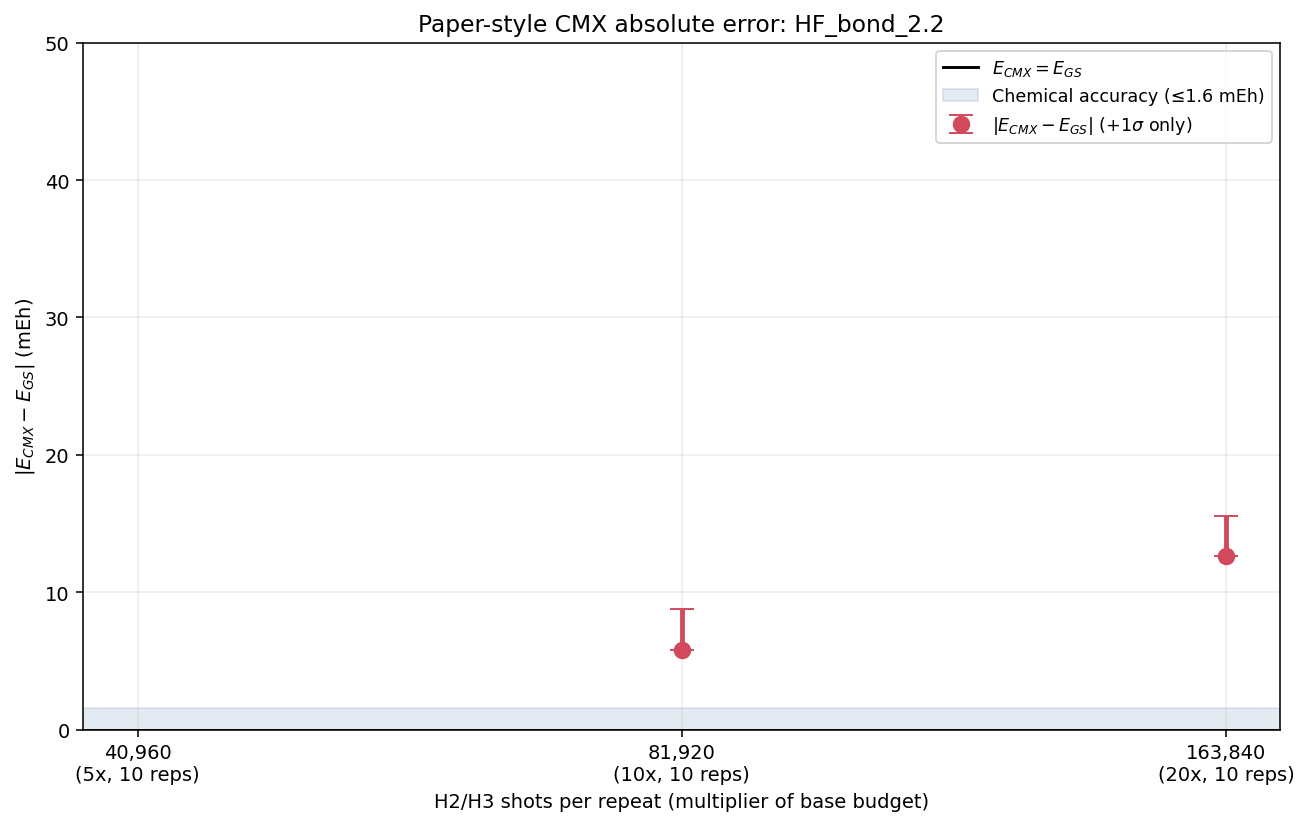

In [8]:
# --- Paper-style CMX absolute error with upward-only uncertainty bars ---
# The marker remains the measured absolute error; only the upper propagated
# uncertainty is drawn (the marker is not shifted to mean - sigma).
if not cme_by_multiplier:
    print("No CMX/CME sweep results found in", RUN_DIR)
else:
    absolute_error_meh = np.abs(signed_error_meh)
    upward_yerr_meh = np.vstack(
        [np.zeros_like(yerr_meh), yerr_meh]
    )

    fig, ax = plt.subplots(figsize=(9.5, 6.0))
    ax.errorbar(
        shot_counts,
        absolute_error_meh,
        yerr=upward_yerr_meh,
        marker="o",
        linestyle="none",
        markersize=8,
        linewidth=2.5,
        capsize=6,
        color="#d1495b",
        label=rf"$|E_{{CMX}}-E_{{GS}}|$ (+{CMX_ERRORBAR_SIGMAS}$\sigma$ only)",
    )
    ax.axhline(0.0, color="black", linewidth=1.5, label="$E_{CMX}=E_{GS}$")
    ax.axhspan(
        0.0,
        1.6,
        color="#4c78a8",
        alpha=0.15,
        label="Chemical accuracy (≤1.6 mEh)",
    )

    ax.set_xscale("log", base=2)
    ax.set_xticks(shot_counts)
    ax.set_xticklabels(shot_tick_labels)
    ax.set_ylim(-50.0, 50.0)
    ax.set_ylim(bottom=0.0)
    ax.minorticks_off()
    ax.set_xlabel("H2/H3 shots per repeat (multiplier of base budget)")
    ax.set_ylabel(r"$|E_{CMX}-E_{GS}|$ (mEh)")
    ax.set_title(f"Paper-style CMX absolute error: {RUN_DIR.name}")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=9, loc="best")
    fig.tight_layout()
    plt.show()

In [7]:
# --- Total shot count (CMX + VQE) for each CMX shot-budget multiplier ---
if not cme_by_multiplier:
    print("No CMX/CME sweep results found in", RUN_DIR)
else:
    cost_model = (vqe_results or {}).get("cost_model", {})
    vqe_total_shots = int(cost_model.get("total_shots_est", 0))
    # Each CMX moment (<H>, <H^2>, <H^3>) is measured through one CDR call:
    # (num_circuits training circuits + 1 target) energy evals at the moment's shot budget.
    evals_per_cdr_call = int(cost_model.get("energy_evals_per_cdr_call", 1))

    if vqe_total_shots == 0:
        print("Warning: no VQE cost model found; VQE shots counted as 0.")

    print(f"VQE total shots (all iterations, incl. CDR training): {vqe_total_shots:,}")
    print(f"CMX CDR energy evals per moment measurement: {evals_per_cdr_call}\n")

    header = (
        f"{'mult':>5}  {'CMX moment shots (H+H2+H3)':>27}  "
        f"{'CMX shots incl. CDR':>20}  {'VQE shots':>14}  {'TOTAL (CMX+VQE)':>16}"
    )
    print(header)
    print("-" * len(header))
    for mult, result in sorted((int(k), v) for k, v in cme_by_multiplier.items()):
        shots = result["shots"]
        cmx_moment_shots = int(shots["H"]) + int(shots["H2"]) + int(shots["H3"])
        cmx_total_shots = cmx_moment_shots * evals_per_cdr_call
        grand_total = cmx_total_shots + vqe_total_shots
        print(
            f"{mult:>4}x  {cmx_moment_shots:>27,}  "
            f"{cmx_total_shots:>20,}  {vqe_total_shots:>14,}  {grand_total:>16,}"
        )

VQE total shots (all iterations, incl. CDR training): 27,172,864
CMX CDR energy evals per moment measurement: 31

 mult   CMX moment shots (H+H2+H3)   CMX shots incl. CDR       VQE shots   TOTAL (CMX+VQE)
------------------------------------------------------------------------------------------
   5x                      122,880             3,809,280      27,172,864        30,982,144
  10x                      245,760             7,618,560      27,172,864        34,791,424
  20x                      491,520            15,237,120      27,172,864        42,409,984
